In [ ]:
%pip install matplotlib

In [1]:
import networkx as nx
from shapely.ops import unary_union
from shapely.geometry import Polygon
from shapely.ops import polygonize
from skimage import measure
import numpy as np
import matplotlib.pyplot as plt
import cv2

from ocrd_utils import points_from_polygon
from ocrd_models.ocrd_page import (
    CoordsType,
    TextRegionType,)

from PIL import Image

## Union polygons

In [ ]:
poylgon1 = Polygon([(0, 0), (1, 0), (1, 1), (0, 1)])
poylgon2 = Polygon([(0.5, 0.5), (1.5, 0.5), (1.5, 1.5), (0.5, 1.5)])

In [ ]:
polygons = [poylgon1, poylgon2]

In [ ]:
type(polygons)

In [ ]:
uf = nx.utils.UnionFind(polygons)
uf

In [ ]:
uf[polygons[0]]

In [ ]:
for s in uf.to_sets():
    print(s)

In [ ]:
uf.union(polygons[0], polygons[1])
uf

In [ ]:
uf.to_sets()

In [ ]:
for s in uf.to_sets():
    print(s)

In [ ]:
polygons.append(Polygon([(2, 2), (3, 2), (3, 3), (2, 3)]))
polygons.append(Polygon([(2.5, 2.5), (3.5, 2.5), (3.5, 3.5), (2.5, 3.5)]))

In [ ]:
boundaries = [p.boundary for p in polygons]
boundaries

In [ ]:
test = unary_union(boundaries)
test

In [ ]:
po_test = polygonize(test)
for p in po_test:
    print(p)

## Find contours

In [ ]:
# create a RGB image with three rectangles, two have hole inside
# the first one has an island inside the hole
h, w = 100, 100
image = np.zeros((h, w, 3), dtype=np.uint8)
image[10:40, 10:40] = [231, 76, 60] # first rectangle
image[20:30, 20:30] = 0 # hole in the first rectangle
image[25:27, 25:27] = [52, 152, 219] # island in the hole of the first rectangle
image[50:80, 50:80] = [230, 126, 34] # second rectangle
image[60:70, 60:70] = 0 # hole in the second rectangle

image[60:90, 10:40] = [0, 204, 0] # normal rectangle without hole

In [ ]:
mask_red = np.all(image == [231, 76, 60], axis=-1)
mask_orange = np.all(image == [230, 126, 34], axis=-1)
mask_blue = np.all(image == [52, 152, 219], axis=-1)
mask_green = np.all(image == [0, 204, 0], axis=-1)

In [ ]:
# display the image
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')
plt.show()

### With skimage

In [ ]:
# use find_countours to find contours in the image
contours_red = measure.find_contours(mask_red, 0.5)
contours_red

In [ ]:
# draw the contours on the image
plt.imshow(image)
for contour in contours_red:
    plt.plot(contour[:, 1], contour[:, 0], linewidth=5) # contour[:, 1] is x or column, contour[:, 0] is y or row
plt.title('Contours of the red part')
plt.axis('off')
plt.show()

### Using OpenCV to find contours instead of skimage

In [ ]:
# prepare masks
mask_red = mask_red.astype(np.uint8) * 255 # must be 0 and 255 for cv2.findContours
mask_orange = mask_orange.astype(np.uint8) * 255
mask_blue = mask_blue.astype(np.uint8) * 255

In [ ]:
# find contours using OpenCV
contours_red_cv, hierachy_red = cv2.findContours(
    mask_red,
    mode=cv2.RETR_TREE, # retrieve all contours and reconstruct the full hierarchy of nested contours
    method=cv2.CHAIN_APPROX_SIMPLE
)

hierachy_red = hierachy_red[0] # remove extra dimension

contours_red_cv, hierachy_red

In [ ]:
assert len(contours_red_cv) == len(hierachy_red)

In [ ]:
def build_hierachy(contours, hierachy):
    nodes = []

    for i, cnt in enumerate(contours):
        nodes.append({
            "contour": cnt.squeeze(),
            "children": [],
            "parent": hierachy[i][3] # parent index
        })

    # link children to parents
    for i, h in enumerate(hierachy):
        parent_idx = h[3]
        if parent_idx != -1: # if it has a parent
            nodes[parent_idx]["children"].append(i) # add index of child

    return nodes

In [ ]:
def extract_polygons(nodes, idx, is_outer=True):
    node = nodes[idx]

    polygon = {
        "shell": node["contour"],
        "holes": []
    }

    for child_idx in node["children"]:
        if is_outer:
            # children of outer = holes
            hole = nodes[child_idx]["contour"]
            polygon["holes"].append(hole)

            # grandchildren of outer = islands in holes
            for grandchild_idx in nodes[child_idx]["children"]:
                yield from extract_polygons(nodes, grandchild_idx, is_outer=True) # islands are also outer
        else:
            # children of inner = islands in holes
            yield from extract_polygons(nodes, child_idx, is_outer=True) # islands are also outer
    yield polygon

In [ ]:
# get polygons from contours and hierachy
nodes_red = build_hierachy(contours_red_cv, hierachy_red)
polygon_dicts_red = []

for i, node in enumerate(nodes_red):
    if node["parent"] == -1: # if it's an outer contour
        polygon_dicts_red.extend(list(extract_polygons(nodes_red, i, is_outer=True)))

polygon_dicts_red

In [ ]:
assert len(nodes_red) == len(hierachy_red)

In [ ]:
# display the contours and their hierarchy
plt.imshow(image)
for i, node in enumerate(nodes_red):
    contour = node["contour"]
    parent_idx = node["parent"]
    if parent_idx == -1:
        plt.plot(contour[:, 0], contour[:, 1], 'y-', linewidth=2) # outer contour in red
    else:
        plt.plot(contour[:, 0], contour[:, 1], 'b-', linewidth=2) # inner contour in blue
plt.title('Contours and their hierarchy (red: outer, blue: inner)')
plt.axis('off')
plt.show()

In [ ]:
# display the extracted polygons
plt.imshow(image)
for poly in polygon_dicts_red:
    shell = poly["shell"]
    holes = poly["holes"]

    plt.plot(shell[:, 0], shell[:, 1], 'y-', linewidth=2) # shell in yellow
    for hole in holes:
        plt.plot(hole[:, 0], hole[:, 1], 'b-', linewidth=2) # holes in blue
plt.title('Extracted Polygons (yellow: shell, blue: holes)')
plt.axis('off')
plt.show()

In [ ]:
mask_green = mask_green.astype(np.uint8) * 255
contours_green_cv, hierachy_green = cv2.findContours(
    mask_green,
    mode=cv2.RETR_TREE,
    method=cv2.CHAIN_APPROX_SIMPLE
)
hierachy_green

In [ ]:
hierachy_green = hierachy_green[0]

nodes_green = build_hierachy(contours_green_cv, hierachy_green)
polygon_dicts_green = []

for i, node in enumerate(nodes_green):
    if node["parent"] == -1:
        polygon_dicts_green.extend(list(extract_polygons(nodes_green, i, is_outer=True)))

polygon_dicts_green

In [ ]:
test_mask = np.zeros_like(mask_green)
contours_test, hierachy_test = cv2.findContours(
    test_mask,
    mode=cv2.RETR_TREE,
    method=cv2.CHAIN_APPROX_SIMPLE
)
assert hierachy_test is None

## Check if OCR-D RegionType supports polygons with holes

In [ ]:
# convert the above polygon dicts to shapely Polygon objects

shapely_polygons_red = []
for poly_dict in polygon_dicts_red:
    shell = poly_dict["shell"]
    holes = poly_dict["holes"]
    shapely_poly = Polygon(shell, holes)
    shapely_polygons_red.append(shapely_poly)

shapely_polygons_red

In [ ]:
len(shapely_polygons_red[0].interiors)

In [ ]:
# create coords for OCR-D TextRegionType
coords = CoordsType(points_from_polygon(shapely_polygons_red[0].interiors[0].coords))
coords.points

## Debugging...

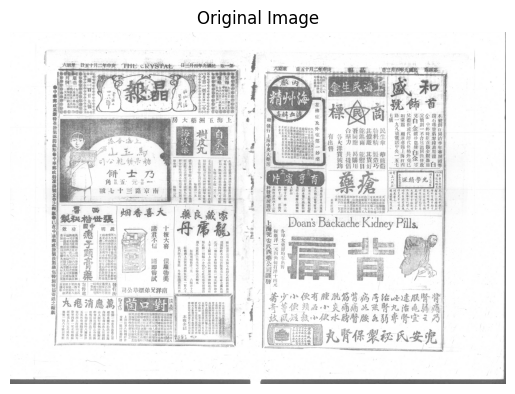

In [2]:
org_imgage_path = "/home/tuyen/SSC_repos/ocrd_eynollah/data/jb_0129_1920-04-03_0001to0004.png"
org_image = Image.open(org_imgage_path)
org_image_array = np.array(org_image)
plt.imshow(org_image_array, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

In [3]:
org_image_array.shape

(3456, 4864)

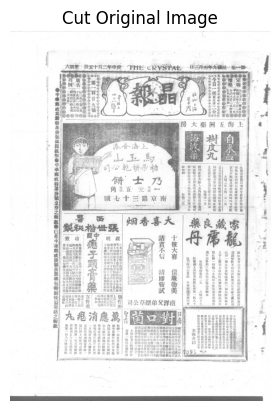

In [4]:
cut_org_image_array = org_image_array[:, :2432]
plt.imshow(cut_org_image_array, cmap='gray')
plt.title('Cut Original Image')
plt.axis('off')
plt.show()

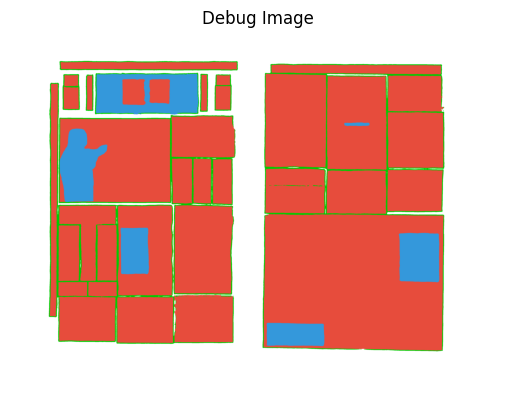

In [5]:
debug_img_path = "/home/tuyen/SSC_repos/ocrd_eynollah/myworkspace/OCR-D-EYNOLLAH/OCR-D-EYNOLLAH_PAGE_001_layout.png"
debug_img = Image.open(debug_img_path)
debug_img_array = np.array(debug_img)
plt.imshow(debug_img_array)
plt.title('Debug Image')
plt.axis('off')
plt.show()

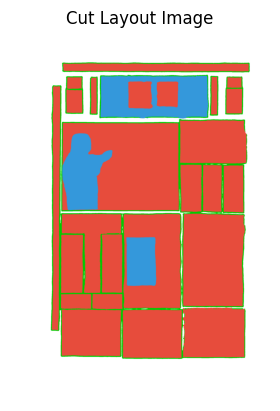

In [6]:
cut_layout_array = debug_img_array[:, :2432]
plt.imshow(cut_layout_array)
plt.title('Cut Layout Image')
plt.axis('off')
plt.show()

In [7]:
def _build_contours_hierarchy(
    contours: list[np.ndarray], hierarchy: np.ndarray
) -> list[dict]:
    """Build a hierarchy of contours based on the hierarchy information from OpenCV.

    Args:
        contours (list[np.ndarray]): List of contours as returned by cv2.findContours.
            Each contour is a NumPy array of shape (n_points, 1, 2)
            where n_points is the number of points in the contour.
        hierarchy (np.ndarray): Hierarchy information as returned by cv2.findContours.
            It is a NumPy array of shape (n_contours, 4)
            where each row corresponds to a contour and contains the indices of
            the next, previous, first child, and parent contours.
            `hierarchy` should be `hierarchy[0]` if cv2.findContours is called with cv2.RETR_TREE.

    Returns:
        list[dict]: A list of dictionaries representing the contour hierarchy.
            Each dictionary has the following keys:
            - "contour": The contour points as a NumPy array of shape (n_points, 2).
            - "children": A list of indices of child contours in the returned contour list.
            - "parent": The index of the parent contour in the returned contour list,
                or -1 if there is no parent.
    """
    nodes = []

    for i, cnt in enumerate(contours):
        nodes.append(
            {
                "contour": cnt.reshape(
                    -1, 2
                ),  # reshape to 2 columns for x and y coordinates, infer the number of points with -1 placeholder
                "children": [],
                "parent": hierarchy[i][3],  # parent index
            }
        )

    # link children to parents
    for i, h in enumerate(hierarchy):
        parent_idx = h[3]
        if parent_idx != -1:  # if it has a parent
            nodes[parent_idx]["children"].append(i)  # add index of child

    return nodes

def _extract_polygons_from_hierarchy_contours(
    nodes: list[dict], idx: int, is_outer: bool = True
):
    """Recursively extract polygons from the contour hierarchy.

    Args:
        nodes (list[dict]): The contour hierarchy as returned by `_build_contours_hierarchy`.
        idx (int): The index of the current contour node to process.
        is_outer (bool): Whether the current contour is an outer contour (True) or a hole (False).
            If there is a child inside a hole, this child is also an outer contour (island in the hole).

    Yields:
        PolygonDict: A dictionary representing a polygon with the following keys:
            - "shell": A list of (x, y) tuples representing the exterior boundary of the polygon.
            - "holes": A list of lists of (x, y) tuples, where each inner list represents a hole in the polygon.
    """
    node = nodes[idx]

    polygon = {"shell": node["contour"], "holes": []}

    for child_idx in node["children"]:
        if is_outer:
            # children of outer = holes
            hole = nodes[child_idx]["contour"]
            polygon["holes"].append(hole)

            # grandchildren of outer = islands in holes
            for grandchild_idx in nodes[child_idx]["children"]:
                yield from _extract_polygons_from_hierarchy_contours(
                    nodes, grandchild_idx, is_outer=True
                )  # islands are also outer
        else:
            # children of inner = islands in holes
            yield from _extract_polygons_from_hierarchy_contours(
                nodes, child_idx, is_outer=True
            )  # islands are also outer
    yield polygon

def _close_ring(ring: np.ndarray) -> np.ndarray:
    """Ensure that a ring of coordinates is closed
    by checking the first and last points and appending
    the first point to the end if they are not the same.
    """
    if not np.array_equal(ring[0], ring[-1]):
        ring = np.vstack([ring, ring[0]])
    return ring

def _is_valid_ring(ring: np.ndarray) -> bool:
    """Check if a ring of coordinates is valid for creating a polygon.
    A valid ring must have at least 4 points (including the closing point)
    and must be closed (the first and last points must be the same).
    """
    return len(ring) >= 4 and np.array_equal(ring[0], ring[-1])

def _create_polygon(
    shell: np.ndarray, holes: list[np.ndarray]
) -> Polygon | None:
    """Create a Shapely Polygon from a shell and holes, ensuring that the rings are valid.
    If the shell or any hole is not a valid ring, return None.
    """
    shell = _close_ring(shell)
    if not _is_valid_ring(shell):
        return None

    valid_holes = []
    for hole in holes:
        hole = _close_ring(hole)
        if _is_valid_ring(hole):
            valid_holes.append(hole)

    try:
        polygon = Polygon(shell=shell, holes=valid_holes)
        if not polygon.is_empty:
            return polygon
        else:
            return None
    except Exception as e:
        return None

def _polygons_from_rgb_array(
   arr: np.ndarray, skip_colors=((255, 255, 255),)
) -> dict[tuple[int, int, int], list[Polygon]]:
    """Convert an RGB NumPy array into Shapely polygons grouped by RGB value."""

    polygons_by_color = dict()

    # Get unique RGB values
    colors = np.unique(arr.reshape(-1, 3), axis=0)

    for color in colors:
        color = tuple(int(c) for c in color)
        if color in skip_colors:
            continue

        # Create mask for this RGB value
        mask = np.all(arr == color, axis=-1)
        mask = (
            mask.astype(np.uint8) * 255
        )  # convert boolean mask to uint8 (0 and 255) for contour detection

        # debugging
        plt.imshow(mask, cmap='gray')
        plt.title(f'Mask for color {color}')
        plt.axis('off')
        plt.show()

        # Extract contours with opencv
        contours, hierachy = cv2.findContours(
            mask,
            mode=cv2.RETR_TREE,  # retrieve all contours and reconstruct the full hierarchy of nested contours
            method=cv2.CHAIN_APPROX_SIMPLE,
        )
        if hierachy is None:  # no contours found
            continue

        # debugging, show contours on the mask
        plt.imshow(mask, cmap='gray')
        for contour in contours:
            plt.plot(contour[:, 0, 0], contour[:, 0, 1], linewidth=2) # contour[:, 0, 0] is x or column, contour[:, 0, 1] is y or row
        plt.title(f'Contours for color {color}')
        plt.axis('off')
        plt.show()

        hierachy = hierachy[
            0
        ]  # cv2.findContours returns hierarchy with shape (1, n_contours, 4)

        # extract polygons from contours and hierarchy
        nodes = _build_contours_hierarchy(contours, hierachy)
        polygon_dicts = []

        for i, node in enumerate(nodes):
            if (
                node["parent"] == -1
            ):  # only process outer contours (those without parent)
                polygon_dicts.extend(
                    list(
                        _extract_polygons_from_hierarchy_contours(
                            nodes, i, is_outer=True
                        )
                    )
                )

        # convert polygon dicts to shapely Polygons and add to the result
        for poly_dict in polygon_dicts:
            polygon = _create_polygon(poly_dict["shell"], poly_dict["holes"])
            if polygon is not None:
                values = polygons_by_color.get(color, [])
                values.append(polygon)
                polygons_by_color[color] = values

    return polygons_by_color

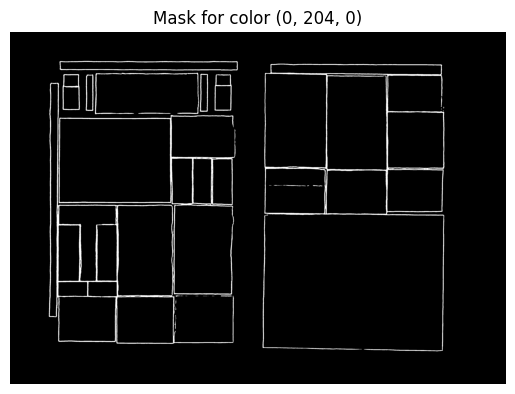

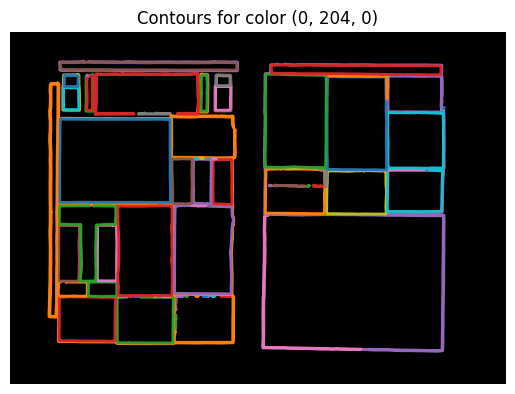

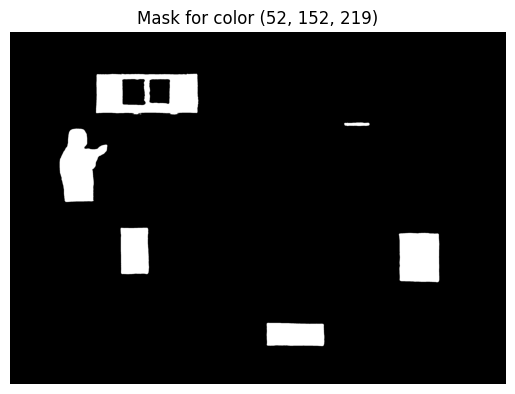

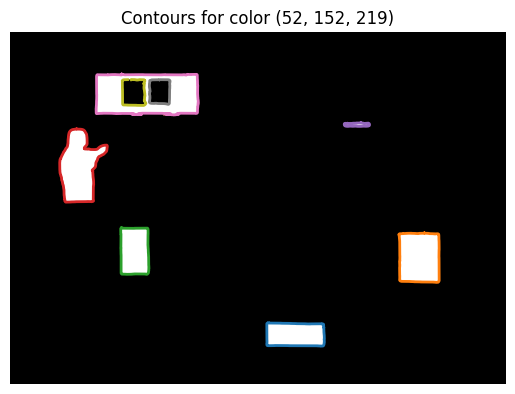

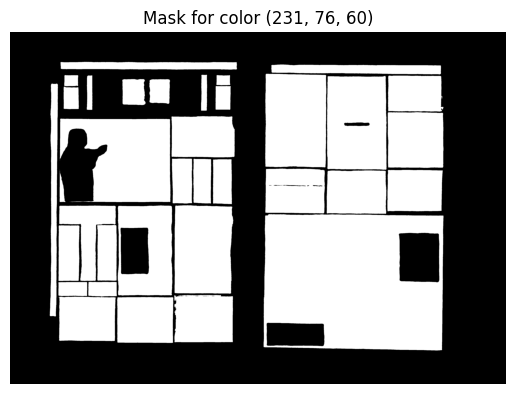

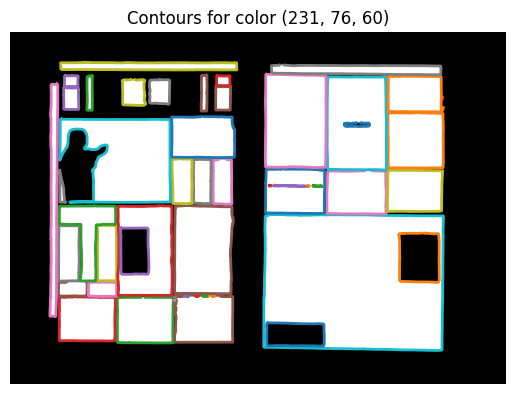

{(0,
  204,
  0): [<POLYGON ((1615 2855, 1614 2856, 1614 2857, 1615 2858, 1615 2855))>, <POLYGON ((1623 2781, 1622 2782, 1622 2790, 1623 2791, 1623 2795, 1624 2796,...>, <POLYGON ((1610 2762, 1610 2769, 1611 2769, 1611 2763, 1610 2762))>, <POLYGON ((1623 2698, 1623 2700, 1622 2701, 1622 2704, 1623 2705, 1623 2708,...>, <POLYGON ((1627 2631, 1627 2632, 1626 2633, 1627 2634, 1627 2635, 1628 2636,...>, <POLYGON ((1940 2594, 1939 2595, 1938 2595, 1945 2595, 1944 2594, 1940 2594))>, <POLYGON ((1985 2593, 1984 2594, 1979 2594, 1980 2594, 1981 2595, 2000 2595,...>, <POLYGON ((1899 2593, 1898 2594, 1893 2594, 1893 2595, 1932 2595, 1931 2594,...>, <POLYGON ((1831 2593, 1830 2594, 1819 2594, 1819 2595, 1846 2595, 1847 2594,...>, <POLYGON ((1718 2593, 1717 2594, 1728 2594, 1729 2595, 1737 2595, 1738 2594,...>, <POLYGON ((2069 2590, 2069 2593, 2068 2594, 2067 2594, 2069 2596, 2069 2597,...>, <POLYGON ((1632 2589, 1631 2590, 1630 2590, 1629 2591, 1625 2591, 1624 2592,...>, <POLYGON ((2528 1797, 252

In [8]:
test_polygons = _polygons_from_rgb_array(debug_img_array)
test_polygons

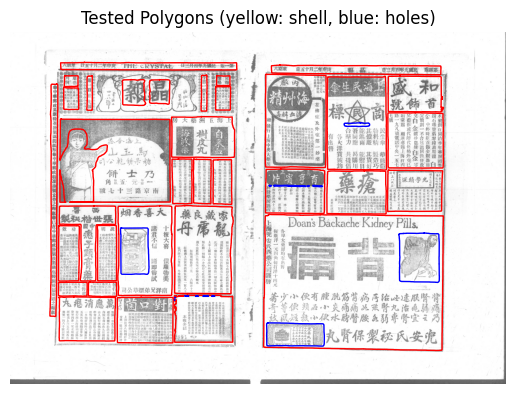

In [9]:
# show the tested polygons
plt.imshow(org_image_array, cmap='gray')
for poly in test_polygons.get((231, 76, 60)):

    x, y = poly.exterior.xy
    plt.plot(x, y, 'r-', linewidth=1) # shell in red
    for hole in poly.interiors:
        xh, yh = hole.xy
        plt.plot(xh, yh, 'b-', linewidth=1) # holes in blue
plt.title('Tested Polygons (yellow: shell, blue: holes)')
plt.axis('off')
plt.show()

In [11]:
# count how many holes in total for each color
for color, polys in test_polygons.items():
    total_holes = 0
    for poly in polys:
        total_holes += len(poly.interiors)
    print(f"Color {color} has {total_holes} holes in total.")

Color (0, 204, 0) has 63 holes in total.
Color (52, 152, 219) has 2 holes in total.
Color (231, 76, 60) has 17 holes in total.
